#### Import libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

#### Load data

In [2]:
df = pd.read_csv('data_set/dating_app_behavior_encoded.csv')

print(df.shape)

(50000, 80)


#### Target and features

In [3]:
target = 'match_outcomes'

numeric_df = df.drop(columns=['interest_tags'], errors='ignore').select_dtypes(include='number')
corr = numeric_df.corr()[target].drop(target).abs().sort_values(ascending=False)

selected_features = corr.head(12).index.tolist()

X = df[selected_features]
y = df[target]

print('Target:', target)
print('Selected features:')
print(selected_features)
print('Number of classes:', y.nunique())

Target: match_outcomes
Selected features:
['swipe_time_of_day_Morning', 'sexual_orientation_Straight', 'weight_kg', 'location_type_Remote Area', 'relationship_intent_Networking', 'swipe_time_of_day_Evening', 'sexual_orientation_Pansexual', 'sexual_orientation_Bisexual', 'zodiac_sign_Capricorn', 'last_active_hour', 'swipe_time_of_day_Late Night', 'zodiac_sign_Sagittarius']
Number of classes: 10


#### Train test split

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(X_train.shape)
print(X_test.shape)

(40000, 12)
(10000, 12)


#### Try different C values

In [5]:
best_model = None
best_pred = None
best_acc = 0
best_c = None

for c in [0.01, 0.1, 1, 10]:
    model = LogisticRegression(
        C=c,
        max_iter=1000,
        class_weight='balanced',
        random_state=42
    )

    model.fit(X_train_scaled, y_train)
    pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, pred)

    print('C =', c, 'accuracy =', round(acc, 4))

    if acc > best_acc:
        best_acc = acc
        best_model = model
        best_pred = pred
        best_c = c

C = 0.01 accuracy = 0.1011


C = 0.1 accuracy = 0.1014


C = 1 accuracy = 0.1013


C = 10 accuracy = 0.1013


#### Result

In [6]:
print('Best C:', best_c)
print('Accuracy:', round(best_acc, 4))

print(classification_report(y_test, best_pred, zero_division=0))

Best C: 0.1
Accuracy: 0.1014
              precision    recall  f1-score   support

           0       0.11      0.22      0.15      1010
           1       0.12      0.11      0.11      1005
           2       0.11      0.10      0.11      1004
           3       0.15      0.01      0.01       984
           4       0.09      0.10      0.09       992
           5       0.10      0.05      0.06      1016
           6       0.08      0.16      0.11       998
           7       0.11      0.09      0.10       997
           8       0.09      0.06      0.07      1022
           9       0.10      0.13      0.11       972

    accuracy                           0.10     10000
   macro avg       0.11      0.10      0.09     10000
weighted avg       0.11      0.10      0.09     10000



#### Confusion matrix

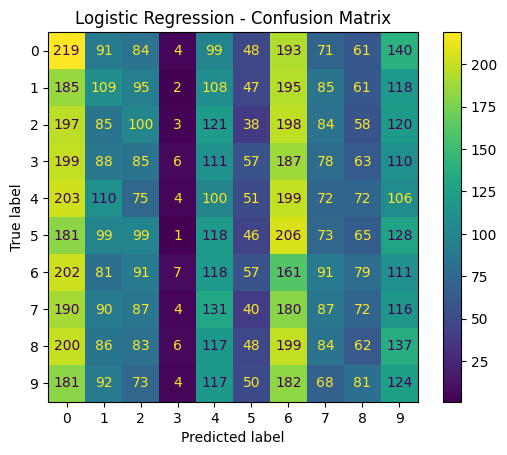

In [7]:
cm = confusion_matrix(y_test, best_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(values_format='d')
plt.title('Logistic Regression - Confusion Matrix')
plt.show()